In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize
from sklearn.linear_model import LogisticRegression

### plot setting

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

%matplotlib widget
# %matplotlib inline

### load

In [3]:
# pca_df will be generated from hidden_stack below
# (no longer pre-computed in simulation.ipynb)

In [4]:
beh_df      = pd.read_csv('../../results/simulations/beh_df.csv')
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,rep,resp,class_pred,net_idx,stim_aligned,resp_aligned
0,0.25,b=0.25,0.025,0,0,0.0,9,0.120335,0.0,0,-0.225,-0.129665
1,0.25,b=0.25,0.025,0,0,0.0,3,0.120335,0.0,0,-0.225,-0.129665
2,0.25,b=0.25,0.025,0,0,0.0,8,0.120335,0.0,0,-0.225,-0.129665
3,0.50,b=0.50,0.025,0,0,0.0,9,0.218308,0.0,0,-0.475,-0.281692
4,0.50,b=0.50,0.025,0,0,0.0,3,0.218308,0.0,0,-0.475,-0.281692


In [5]:
hidden_stack = np.load('../../results/simulations/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, n_trials, n_units)
hidden_mean = hidden_stack.mean(axis=0)
print(f'hidden_mean shape: {hidden_mean.shape}')

# Get boundaries from beh_df instead
boundaries = tuple(sorted(beh_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 180, 10)
hidden_mean shape: (180, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.75))


## Single-Unit

In [6]:
# # Plot all neurons (no averaging) in a grid, with user-defined number of networks
# n_nets_to_plot = 5  # Change this to plot a different number of networks

# n_nets, n_trials, n_units = hidden_stack.shape
# all_neurons = hidden_stack[:n_nets_to_plot].transpose(0, 2, 1).reshape(-1, n_trials)  # shape: (n_nets_to_plot*n_units, 60)

# cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

# # Prepare trial info for coloring
# trial_info = pca_df[['boundary', 'stim']].reset_index(drop=True)

# n_rows = n_nets_to_plot
# n_cols = n_units
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.4, n_rows*2.4), sharex=True)
# axes = axes.flatten()

# for idx, ax in enumerate(axes):
#     if idx >= all_neurons.shape[0]:
#         ax.axis('off')
#         continue
#     neuron_act = all_neurons[idx]
#     for bound in boundaries:
#         mask = trial_info['boundary'] == bound
#         ax.scatter(trial_info.loc[mask, 'stim'], neuron_act[mask],
#                    color=cond_colors[bound], s=10, alpha=0.7)
#         ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
#     ax.set_title(f'Net {idx // n_units + 1}, Unit {idx % n_units + 1}', fontsize=7)
#     ax.set_xlim(0, 1)
#     ax.tick_params(axis='y', labelsize=6)
#     if idx % n_cols == 0:
#         ax.set_ylabel('Activation', fontsize=6)
#     if idx // n_cols == n_rows - 1:
#         ax.set_xlabel('Stim pos', fontsize=6)

# legend_handles = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[bound],
#                markersize=7, label=f'b={bound:.2f}')
#     for bound in boundaries
# ]
# fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
#            bbox_to_anchor=(1.0, 1.0))
# plt.suptitle(f'Single-neuron tuning (first {n_nets_to_plot} networks)')
# plt.tight_layout()
# plt.show()

In [7]:
# # --- Neuron Selectivity Quantification (robust, warnings handled) ---
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# import warnings

# # Data preparation
# n_nets, n_trials, n_units = hidden_stack.shape
# trial_info = pca_df[['boundary', 'class']].reset_index(drop=True)
# trial_info = trial_info.rename(columns={'class': 'class_label'})

# selectivity_types = ['conjunctive', 'mixed', 'class', 'context', 'non-selective']
# selectivity_counts = {k: 0 for k in selectivity_types}
# selectivity_assignments = []
# skipped_neurons = 0

# for net in range(n_nets):
#     for unit in range(n_units):
#         neuron_act = hidden_stack[net, :, unit]
#         df = trial_info.copy()
#         df['activation'] = neuron_act
        
#         try:
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 model = ols('activation ~ C(class_label) + C(boundary) + C(class_label):C(boundary)', data=df).fit()
#                 anova_table = sm.stats.anova_lm(model, typ=2)
#             p_class = anova_table.loc['C(class_label)', 'PR(>F)']
#             p_context = anova_table.loc['C(boundary)', 'PR(>F)']
#             p_interaction = anova_table.loc['C(class_label):C(boundary)', 'PR(>F)']
            
#             # Assign mutually exclusive category
#             if p_interaction < 0.05: selectivity = 'conjunctive'
#             elif p_class < 0.05 and p_context < 0.05: selectivity = 'mixed'
#             elif p_class < 0.05: selectivity = 'class'
#             elif p_context < 0.05: selectivity = 'context'
#             else: selectivity = 'non-selective'
            
#             selectivity_counts[selectivity] += 1
#             selectivity_assignments.append(selectivity)
        
#         except Exception as e:
#             skipped_neurons += 1
#             selectivity_assignments.append('skipped')
#             continue

# # Quantification
# n_total = n_nets * n_units
# selectivity_props = {k: v / n_total for k, v in selectivity_counts.items()}

# # Results summary
# print('Neuron selectivity quantification:')
# print('Type\tCount\tProportion')
# for k in selectivity_types:
#     print(f'{k}\t{selectivity_counts[k]}\t{selectivity_props[k]:.3f}')
# if skipped_neurons > 0:
#     print(f'Skipped neurons due to model errors: {skipped_neurons}')

# # Optional: Bar plot
# plt.figure(figsize=(5, 3))
# plt.bar(selectivity_types, [selectivity_counts[k] for k in selectivity_types], color='skyblue')
# plt.ylabel('Neuron count')
# plt.title('Neuron selectivity distribution')
# plt.show()

### 3 PCs

In [8]:
sns.set(context='paper')
sns.set_style('white')
from matplotlib.lines import Line2D

# average hidden activations across networks for each of the test trials
hidden_mean = hidden_stack.mean(axis=0)

# Create pca_df from test trial metadata (one row per trial, averaged across networks)
pca_df = beh_df[beh_df['net_idx'] == 0][['boundary', 'stim', 'class', 'unique_stim_idx', 'rep']].reset_index(drop=True)

# raw PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]
pca_df['stim_aligned'] = beh_df.loc[pca_df.index, 'stim_aligned'].values

# Print explained variance ratio for each PC
explained_var = pca.explained_variance_ratio_
print('Explained variance by PC (original space):')
for i, var in enumerate(explained_var, 1):
    print(f'  PC{i}: {var*100:.2f}%')

# shared norm over global stim range
shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

# marker per condition
cond_markers = {0.25: 's', 0.50: 'o', 0.75: '^'}

# hidden-centroid-subtracted, then PCA
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    hidden_centered[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)
pca2 = PCA(n_components=2)
pcs2 = pca2.fit_transform(hidden_centered)
pca_df['PC1_aligned'] = pcs2[:, 0]
pca_df['PC2_aligned'] = pcs2[:, 1]
# pca_df['PC3_aligned'] = pcs2[:, 2]

# Print explained variance ratio for each PC
explained_var = pca2.explained_variance_ratio_
print('Explained variance by PC (aligned space):')
for i, var in enumerate(explained_var, 1):
    print(f'  PC{i}: {var*100:.2f}%')

print('PCA setup done.')

Explained variance by PC (original space):
  PC1: 94.96%
  PC2: 4.88%
  PC3: 0.08%
Explained variance by PC (aligned space):
  PC1: 99.65%
  PC2: 0.25%
PCA setup done.


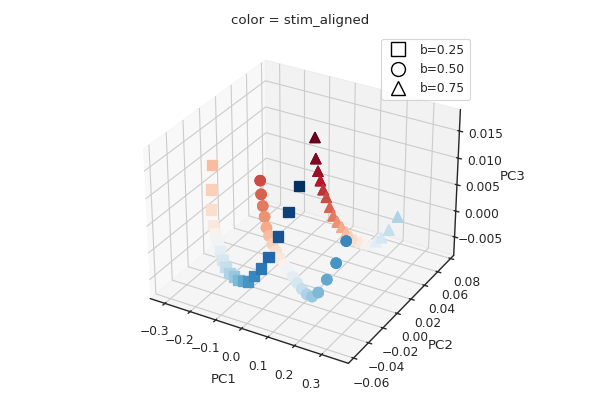

In [9]:
# SETTINGS #######
space = ['Original space', 'Aligned space'][0]
category = ['stim', 'stim_aligned'][1] # stim_aligned = class
# print(f'decoding {category}, {space}')

cmap = plt.cm.RdBu

# view angle
view_elev = 24
view_azim = -65
##################

# Select color values and normalization based on category
color_vals = pca_df[category].values
if category == 'stim_aligned':
    absmax = max(abs(color_vals.min()), abs(color_vals.max()))
    norm = Normalize(vmin=-absmax, vmax=absmax)
else:
    norm = Normalize(vmin=color_vals.min(), vmax=color_vals.max())

# select plotting style based on space
if space == 'Original space':
    pc_cols = ['PC1', 'PC2', 'PC3'] 

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    
    for bound in boundaries:
        cond_df = pca_df[pca_df['boundary'] == bound]
        colors = cmap(norm(cond_df[category].values))
        ax.scatter(cond_df[pc_cols[0]], cond_df[pc_cols[1]], cond_df[pc_cols[2]],
                   c=colors, s=55, alpha=0.9, marker=cond_markers[bound], label=f'b={bound:.2f}')
    ax.set(title=f'color = {category}', xlabel=pc_cols[0], ylabel=pc_cols[1], zlabel=pc_cols[2])

elif space == 'Aligned space':
    pc_cols = ['PC1_aligned', 'PC2_aligned'] 

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111)
    for bound in boundaries:
        cond_df = pca_df[pca_df['boundary'] == bound]
        colors = cmap(norm(cond_df[category].values))
        ax.scatter(cond_df[pc_cols[0]], cond_df[pc_cols[1]],
                   c=colors, s=55, alpha=0.9, marker=cond_markers[bound], label=f'b={bound:.2f}')
    ax.set(title=f'color = {category}', xlabel=pc_cols[0], ylabel=pc_cols[1])
    
legend_handles = [
    plt.Line2D([0], [0], marker=cond_markers[bound], color='w',
               markerfacecolor='none', markeredgecolor='black', markersize=10,
               label=f'b={bound:.2f}')
    for bound in boundaries
]
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
# plt.savefig(f'../../figs/ccn/PCA_{category}_{space}.svg', format='svg')
plt.show()


### Cross-Context Decoding
Train a classifier on one context (boundary), test on another, for all context pairs. The resulting matrix shows decoding accuracy for each (train, test) context pair, using the midpoint (stim > 0.5 vs < 0.5) as the label. Diagonal: within-context; off-diagonal: cross-context generalization.

In [10]:
import numpy as np

def align_contexts(X, context_values):
    """
    Subtract the mean activation vector within each context and return X_aligned.

    Parameters
    ----------
    X : array, shape (n_trials, n_units)
        Trial-by-unit activations.
    context_values : array-like, shape (n_trials,)
        Context label per trial (e.g., pca_df['boundary'].values).

    """

    X_aligned = X.copy()
    for ctx in np.unique(context_values):
        idx = (context_values == ctx)
        mu = X[idx].mean(axis=0)
        X_aligned[idx] = X[idx] - mu
    return X_aligned

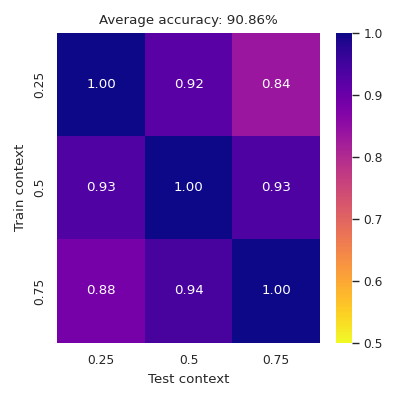

In [12]:
# Context-pairwise midpoint decoding with Logistic Regression: train on one context, test on another

# CHOOSE SETTINGS
decoding_label = ['Stimulus', 'Class'][0] 
alignment_label = ['Original Space', 'Aligned Space'][0]
decoding_target = 0.5 if decoding_label == 'Stimulus' else pca_df['boundary']
alignment = False if alignment_label == 'Original Space' else True

# set variables
n_nets, n_trials, n_units = hidden_stack.shape
contexts = sorted(pca_df['boundary'].unique())
n_contexts = len(contexts)
pairwise_acc = np.zeros((n_nets, n_contexts, n_contexts))

for net in range(n_nets):
    X = hidden_stack[net]    
    if alignment: X = align_contexts(X, pca_df['boundary'].values)

    y = (pca_df['stim'] > decoding_target).astype(int).values  # 1 if stim > decoding_target, else 0
    
    for i, ctx_train in enumerate(contexts): # train context
        train_idx = pca_df['boundary'] == ctx_train
        
        for j, ctx_test in enumerate(contexts): # test context
            test_idx = pca_df['boundary'] == ctx_test

            clf = LogisticRegression(penalty=None)
            clf.fit(X[train_idx], y[train_idx])
            acc = clf.score(X[test_idx], y[test_idx])
            pairwise_acc[net, i, j] = acc

# Average over networks
mean_net_acc = np.nanmean(pairwise_acc, axis=0)

plt.figure(figsize=(4,4))
sns.heatmap(mean_net_acc, annot=True, fmt='.2f', xticklabels=contexts, yticklabels=contexts, cmap='plasma_r', vmin=.5, vmax=1)
plt.xlabel('Test context')
plt.ylabel('Train context')

offdiag = mean_net_acc[~np.eye(n_contexts, dtype=bool)]
# plt.title(f'Cross-Context {decoding_label} Decoding\n({alignment_label})\nAverage accuracy: {np.nanmean(offdiag)*100:.2f}%')
plt.title(f'Average accuracy: {np.nanmean(offdiag)*100:.2f}%')
plt.tight_layout()
# plt.savefig(f'../../figs/ccn/decode_{decoding_label}_{alignment_label}.svg', format='svg')
plt.show()